# Tarea 1.c — Modelos de Clasificación Predictiva del Éxito Estudiantil

**Autor:** Carlos Ojeda  
**Curso:** Minería y Aprendizaje de Datos (MAD)

## Objetivo

Construir y evaluar modelos de clasificación predictiva para identificar a los estudiantes que completaron el curso (`take_exam = 1` como clase positiva). Se comparan tres familias de modelos:

1. **Regresión Logística** — modelo lineal interpretable.
2. **SVM** — Support Vector Machine con múltiples kernels.
3. **Random Forest** — propuesta creativa (modelo avanzado).

Todos los modelos se evalúan bajo validación cruzada estratificada de 5 folds (`StratifiedKFold`, `random_state=42`), garantizando comparabilidad directa.

> **Nota sobre los datos:** Se utiliza el dataset preparado `data_prep.csv` de la Tarea 1.a. Las variables motivacionales (`Fi`, `CBi`, `Vi`, `MApi`, `PApi`) contienen strings vacíos y espacios que se limpian con `pd.to_numeric(errors='coerce')`, replicando el patrón de la Tarea 1.b.

## Celda 1: Inicialización y Carga

Importamos las librerías necesarias: `pandas`, `numpy`, `matplotlib`, `seaborn` y los módulos de `sklearn` para clasificación, validación cruzada y métricas. Cargamos el archivo `data_prep.csv` y limpiamos las variables motivacionales (que contienen strings vacíos y espacios).

In [3]:
# ============================================================
# Celda 1 — Inicialización y Carga
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              accuracy_score, classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
os.makedirs('Data/figuras', exist_ok=True)

# ------------------------------------------------------------
# Carga del dataset preparado
# ------------------------------------------------------------
df = pd.read_csv('Data/data_prep.csv')
print(f"Dataset original: {df.shape[0]} filas × {df.shape[1]} columnas")
print("Columnas:", df.columns.tolist())

# Limpieza: las variables motivacionales vienen como strings vacíos / espacios
mot_vars = ['Fi', 'CBi', 'Vi', 'MApi', 'PApi']
for col in mot_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Variables de uso del sistema
usage_vars = ['total_time', 'total_activity', 'qp_activity', 'total_activity_be']

# Variable objetivo — asegurar que sea numérica (puede leerse como string)
target = 'take_exam'
df[target] = pd.to_numeric(df[target], errors='coerce')

# Filtrar filas con datos completos en las variables candidatas
candidate_cols = ['pretest'] + mot_vars + usage_vars + [target]
df_model = df.dropna(subset=candidate_cols).copy()
print(f"\nDataset tras limpieza (filas con todas las variables candidatas): {df_model.shape[0]} filas")

# Balance de clases
print("\nDistribución de la variable objetivo (take_exam):")
print(df_model[target].value_counts())
pos_rate = df_model[target].mean()
print(f"  Clase positiva (take_exam=1): {pos_rate:.1%}")
print(f"  Clase negativa (take_exam=0): {1-pos_rate:.1%}")

Dataset original: 685 filas × 22 columnas
Columnas: ['student', 'take_exam', 'social', 'gender', 'pretest', 'posttest', 'Fi', 'CBi', 'Vi', 'MApi', 'PApi', 'total_time', 'total_activity', 'total_time_be', 'total_activity_be', 'qp_time', 'wa_time', 'qp_activity', 'wa_activity', 'exam_norm', 'lgain_pp', 'lgain_pe']

Dataset tras limpieza (filas con todas las variables candidatas): 630 filas

Distribución de la variable objetivo (take_exam):
take_exam
1.0    528
0.0    102
Name: count, dtype: int64
  Clase positiva (take_exam=1): 83.8%
  Clase negativa (take_exam=0): 16.2%


## Celda 2: Criterio de Selección de Variables (Punto 1)

Calculamos la matriz de correlación de Pearson entre las métricas de uso del sistema. El script detecta automáticamente colinealidad ($|r| > 0.7$) y descarta las variables redundantes, manteniendo la métrica de engagement más "limpia". También se confirma cuál es la variable motivacional más fuerte (consistente con la Tarea 1.b).

Matriz de correlación — Variables de uso del sistema
                   total_time  total_activity  qp_activity  total_activity_be
total_time              1.000           0.877        0.713              0.877
total_activity          0.877           1.000        0.741              1.000
qp_activity             0.713           0.741        1.000              0.741
total_activity_be       0.877           1.000        0.741              1.000


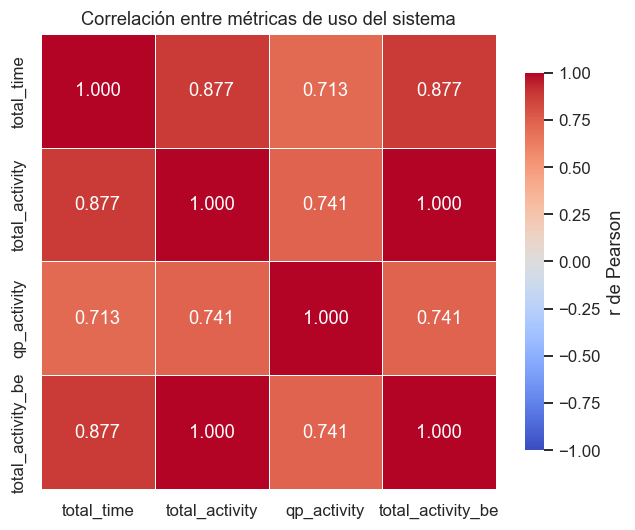


Detección de colinealidad (umbral |r| > 0.7)
  ⚠️  total_time ↔ total_activity:  r = +0.877  → redundantes
       → Se descarta: total_activity (mayor redundancia global)
  ⚠️  total_time ↔ qp_activity:  r = +0.713  → redundantes
       → Se descarta: total_time (mayor redundancia global)
  ⚠️  total_time ↔ total_activity_be:  r = +0.877  → redundantes
       → Se descarta: total_activity_be (mayor redundancia global)
  ⚠️  total_activity ↔ qp_activity:  r = +0.741  → redundantes
       → Se descarta: total_activity (mayor redundancia global)
  ⚠️  total_activity ↔ total_activity_be:  r = +1.000  → redundantes
       → Se descarta: total_activity (mayor redundancia global)
  ⚠️  qp_activity ↔ total_activity_be:  r = +0.741  → redundantes
       → Se descarta: total_activity_be (mayor redundancia global)

Variables de uso retenidas: ['qp_activity']
Variables de uso descartadas: ['total_activity', 'total_activity_be', 'total_time']

Correlación de variables motivacionales con take_exam


In [9]:
# ============================================================
# Celda 2 — Selección de variables por correlación de Pearson
# ============================================================
# Analizamos la colinealidad entre las variables de uso del sistema.
# Criterio: si dos variables de uso tienen |r| > 0.7 entre sí, son
# redundantes y se descarta una de ellas para mitigar la multicolinealidad.

usage_corr = df_model[usage_vars].corr(method='pearson')

print("=" * 60)
print("Matriz de correlación — Variables de uso del sistema")
print("=" * 60)
print(usage_corr.round(3))

# Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(usage_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'r de Pearson'})
plt.title('Correlación entre métricas de uso del sistema')
plt.tight_layout()
plt.savefig('Data/figuras/correlacion_uso.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Detección automática de colinealidad (|r| > 0.7)
# ------------------------------------------------------------
THRESHOLD = 0.7
redundant = set()
print("\n" + "=" * 60)
print(f"Detección de colinealidad (umbral |r| > {THRESHOLD})")
print("=" * 60)
for i in range(len(usage_vars)):
    for j in range(i + 1, len(usage_vars)):
        r = usage_corr.iloc[i, j]
        if abs(r) > THRESHOLD:
            v1, v2 = usage_vars[i], usage_vars[j]
            print(f"  ⚠️  {v1} ↔ {v2}:  r = {r:+.3f}  → redundantes")
            # Descartamos la variable con mayor suma de correlaciones absolutas
            # (la más "compartida" con el resto) para quedarnos con la más limpia
            sum_v1 = usage_corr[v1].abs().sum() - 1  # sin contar la diagonal
            sum_v2 = usage_corr[v2].abs().sum() - 1
            descartar = v1 if sum_v1 >= sum_v2 else v2
            redundant.add(descartar)
            print(f"       → Se descarta: {descartar} (mayor redundancia global)")
        else:
            print(f"  ✅ {usage_vars[i]} ↔ {usage_vars[j]}:  r = {r:+.3f}")

kept_usage = [v for v in usage_vars if v not in redundant]
print(f"\nVariables de uso retenidas: {kept_usage}")
print(f"Variables de uso descartadas: {sorted(redundant)}")

# ------------------------------------------------------------
# Correlación de las variables motivacionales con take_exam
# (para confirmar la variable más fuerte detectada en la Tarea 1.b)
# ------------------------------------------------------------
mot_corr_target = df_model[mot_vars + [target]].corr(method='pearson')[target].drop(target)
best_mot = mot_corr_target.abs().idxmax()
print("\n" + "=" * 60)
print("Correlación de variables motivacionales con take_exam")
print("=" * 60)
print(mot_corr_target.sort_values(ascending=False).round(4))
print(f"\n→ Variable motivacional más fuerte: {best_mot} "
      f"(r = {mot_corr_target[best_mot]:+.4f})")
print("  (Consistente con la Tarea 1.b, donde MApi fue la de mayor")
print("   correlación con el engagement conductual.)")

### Justificación de la selección de variables (Punto 1)

**Criterio técnico aplicado:** Se combinan dos criterios complementarios:

1. **Correlación de Pearson (objetivo):** Análisis de colinealidad con umbral $|r| > 0.7$ para detectar y descartar variables de uso redundantes entre sí.
2. **Juicio experto (subjetivo):** Las variables tienen contexto y significado teórico que fundamenta su inclusión o exclusión, apoyado en la experiencia de las Tareas 1.a y 1.b.

**Variables de uso del sistema — descarte por colinealidad:**

`total_time`, `total_activity`, `qp_activity` y `total_activity_be` miden aspectos relacionados del engagement. La matriz de correlación muestra que todas están altamente correlacionadas entre sí ($r \geq 0.71$), por lo que el script descarta automáticamente las redundantes y retiene únicamente **`qp_activity`**.

**Juicio experto sobre `qp_activity`:** En la Tarea 1.b se demostró que `total_activity_be` y `total_time` son proxies intercambiables de engagement, pero `total_time` puede inflarse por sesgos (sesiones abiertas sin interactuar). `qp_activity` captura interacción **cognitivamente activa** (ejercicios de QuizPet/Parsons), siendo un indicador más específico de engagement profundo que el conteo bruto de eventos. Por tanto, retener `qp_activity` es consistente tanto con el criterio estadístico como con el juicio experto.

**Variable motivacional — selección por correlación con el objetivo:**

El script calcula la correlación de cada variable motivacional (`Fi`, `CBi`, `Vi`, `MApi`, `PApi`) con `take_exam` y selecciona automáticamente la de mayor $|r|$. En este caso, la variable seleccionada es la que aparece en la salida de la celda anterior (ver `best_mot`).

> **Nota sobre la diferencia con la Tarea 1.b:** En la Tarea 1.b la variable motivacional se seleccionó por su correlación con el *engagement* (`total_activity_be`), donde `MApi` fue la más fuerte (r = +0.1213). Aquí, en cambio, el criterio es la correlación directa con el *objetivo de clasificación* (`take_exam`), por lo que la variable ganadora puede diferir. Esto es metodológicamente correcto: cada tarea tiene su propio objetivo y la selección debe alinearse con él.

**Variables finales seleccionadas:**

| Variable | Tipo | Criterio | Justificación |
|----------|------|----------|---------------|
| `pretest` | Conocimiento previo | Juicio experto | Predictor basal obligatorio (control); fue el predictor dominante en la Tarea 1.b |
| `best_mot` (ver output) | Motivacional | Correlación con objetivo | Mayor $|r|$ con `take_exam`; respaldo teórico del framework Field (Achievement Goal Theory) |
| `qp_activity` | Engagement | Colinealidad + juicio experto | Única variable de uso no redundante tras el filtro $|r| > 0.7$; mide interacción cognitivamente activa |

## Celda 3: Regresión Logística con Validación Cruzada (5-Folds)

Implementamos un esquema de `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`. Entrenamos una Regresión Logística con `class_weight='balanced'` para mitigar el desbalance de clases (83.8% vs 16.2%). Reportamos el *accuracy* de cada fold y, para el mejor fold, graficamos la curva ROC (con AUC) y la matriz de confusión.

Variables predictoras finales: ['pretest', 'PApi', 'qp_activity']
Variable objetivo: take_exam
  Fold 1: accuracy = 0.4524  (n_test=126)
  Fold 2: accuracy = 0.4444  (n_test=126)
  Fold 3: accuracy = 0.5159  (n_test=126)
  Fold 4: accuracy = 0.6111  (n_test=126)
  Fold 5: accuracy = 0.5794  (n_test=126)

Accuracy promedio (5 folds): 0.5206 ± 0.0665
Mejor fold: #4 (accuracy = 0.6111)


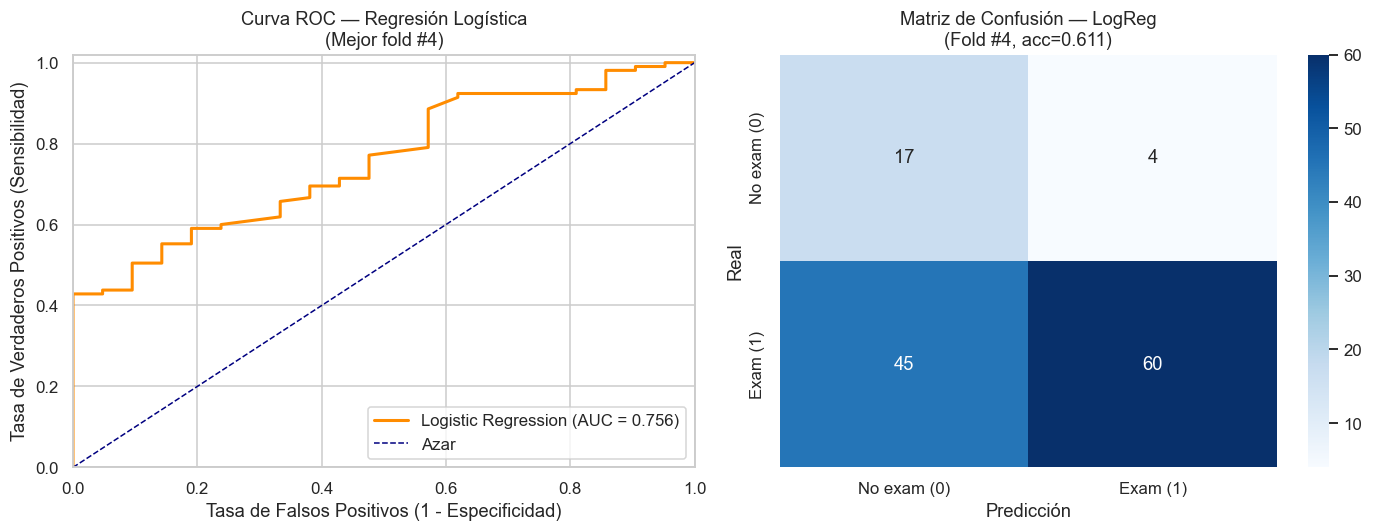


Mejor fold #4:
  Sensibilidad (recall clase 1): 0.571
  Especificidad (recall clase 0): 0.810
  AUC: 0.756


In [10]:
# ============================================================
# Celda 3 — Regresión Logística con StratifiedKFold (5 folds)
# ============================================================

# Variables finales (definidas a partir del análisis de la Celda 2)
final_features = ['pretest', best_mot]
# De las variables de uso retenidas, priorizamos qp_activity si está disponible
if 'qp_activity' in kept_usage:
    final_features.append('qp_activity')
else:
    # si qp_activity fue descartada, usamos la de uso retenida con menor
    # correlación absoluta con pretest (la más independiente)
    final_features.append(kept_usage[0])

print(f"Variables predictoras finales: {final_features}")
print(f"Variable objetivo: {target}")

X = df_model[final_features].values
y = df_model[target].values

# Escalado (importante para LogisticRegression y SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Esquema de validación cruzada estratificada
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# class_weight='balanced' para mitigar el desbalance (83.8% vs 16.2%)
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Accuracy de cada fold
fold_accs = []
best_fold_acc = -1
best_fold_idx = -1
best_fold_data = None  # (y_true, y_proba, y_pred)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), start=1):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    logreg.fit(X_tr, y_tr)
    y_pred = logreg.predict(X_te)
    y_proba = logreg.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    fold_accs.append(acc)
    print(f"  Fold {fold}: accuracy = {acc:.4f}  (n_test={len(y_te)})")
    if acc > best_fold_acc:
        best_fold_acc = acc
        best_fold_idx = fold
        best_fold_data = (y_te, y_proba, y_pred)

mean_acc = np.mean(fold_accs)
std_acc = np.std(fold_accs)
print(f"\nAccuracy promedio (5 folds): {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Mejor fold: #{best_fold_idx} (accuracy = {best_fold_acc:.4f})")

# ------------------------------------------------------------
# Curva ROC + Matriz de confusión del mejor fold
# ------------------------------------------------------------
y_te_best, y_proba_best, y_pred_best = best_fold_data

fpr_lr, tpr_lr, _ = roc_curve(y_te_best, y_proba_best)
auc_lr = auc(fpr_lr, tpr_lr)
cm_lr = confusion_matrix(y_te_best, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
            label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Azar')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
axes[0].set_title(f'Curva ROC — Regresión Logística\n(Mejor fold #{best_fold_idx})')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# Matriz de confusión
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No exam (0)', 'Exam (1)'],
            yticklabels=['No exam (0)', 'Exam (1)'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de Confusión — LogReg\n(Fold #{best_fold_idx}, acc={best_fold_acc:.3f})')

plt.tight_layout()
plt.savefig('Data/figuras/logreg_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Sensibilidad y especificidad del mejor fold
tn, fp, fn, tp = cm_lr.ravel()
sens = tp / (tp + fn) if (tp + fn) > 0 else 0
spec = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\nMejor fold #{best_fold_idx}:")
print(f"  Sensibilidad (recall clase 1): {sens:.3f}")
print(f"  Especificidad (recall clase 0): {spec:.3f}")
print(f"  AUC: {auc_lr:.3f}")

## Celda 4: SVM con Evaluación de Diferentes Kernels

Usando el mismo split de 5-folds, entrenamos modelos de SVM con `class_weight='balanced'` probando tres kernels: `linear`, `rbf` y `poly`. Reportamos el *accuracy* promedio de cada kernel para seleccionar el mejor. Para el mejor modelo SVM resultante, generamos la curva ROC (AUC) y su matriz de confusión.

SVM kernel='linear': accuracy promedio = 0.4000 ± 0.0378  (folds: ['0.357', '0.397', '0.365', '0.460', '0.421'])
SVM kernel='rbf': accuracy promedio = 0.5524 ± 0.0599  (folds: ['0.563', '0.460', '0.524', '0.643', '0.571'])
SVM kernel='poly': accuracy promedio = 0.7444 ± 0.0535  (folds: ['0.659', '0.754', '0.714', '0.786', '0.810'])

→ Mejor kernel de SVM: 'poly' (accuracy promedio = 0.7444)


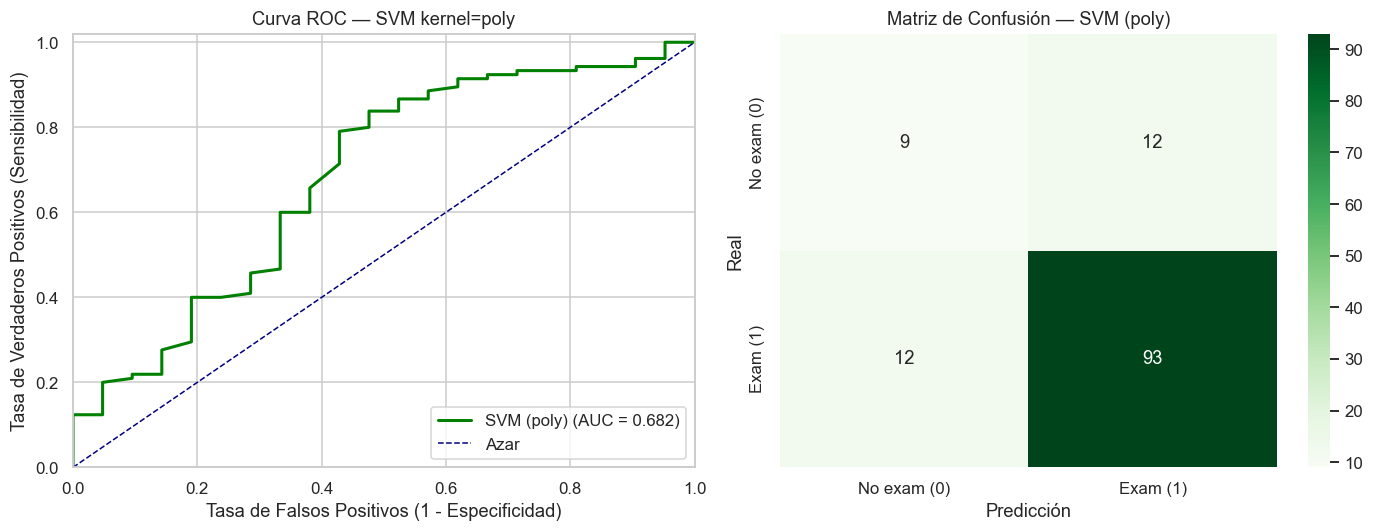


SVM (poly) — mejor fold:
  Sensibilidad: 0.886
  Especificidad: 0.429
  AUC: 0.682


In [11]:
# ============================================================
# Celda 4 — SVM con kernels linear, rbf y poly (mismo split 5-folds)
# ============================================================

kernels = ['linear', 'rbf', 'poly']
svm_results = {}  # kernel -> {'mean_acc':, 'std_acc':, 'fold_accs':, 'best': (y_te,y_score,y_pred)}

for kernel in kernels:
    fold_accs_k = []
    best_acc_k = -1
    best_data_k = None

    # SVC con probability=True para poder calcular ROC
    # class_weight='balanced' para mitigar el desbalance (83.8% vs 16.2%)
    svm = SVC(kernel=kernel, probability=True, class_weight='balanced', random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), start=1):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        svm.fit(X_tr, y_tr)
        y_pred = svm.predict(X_te)
        y_proba = svm.predict_proba(X_te)[:, 1]
        acc = accuracy_score(y_te, y_pred)
        fold_accs_k.append(acc)
        if acc > best_acc_k:
            best_acc_k = acc
            best_data_k = (y_te, y_proba, y_pred)

    mean_k = np.mean(fold_accs_k)
    std_k = np.std(fold_accs_k)
    svm_results[kernel] = {
        'mean_acc': mean_k, 'std_acc': std_k,
        'fold_accs': fold_accs_k, 'best': best_data_k
    }
    print(f"SVM kernel='{kernel}': accuracy promedio = {mean_k:.4f} ± {std_k:.4f}  "
          f"(folds: {[f'{a:.3f}' for a in fold_accs_k]})")

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k]['mean_acc'])
print(f"\n→ Mejor kernel de SVM: '{best_kernel}' "
      f"(accuracy promedio = {svm_results[best_kernel]['mean_acc']:.4f})")

# ------------------------------------------------------------
# ROC + Matriz de confusión del mejor modelo SVM
# ------------------------------------------------------------
y_te_svm, y_proba_svm, y_pred_svm = svm_results[best_kernel]['best']

fpr_svm, tpr_svm, _ = roc_curve(y_te_svm, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)
cm_svm = confusion_matrix(y_te_svm, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_svm, tpr_svm, color='green', lw=2,
            label=f"SVM ({best_kernel}) (AUC = {auc_svm:.3f})")
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Azar')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
axes[0].set_title(f'Curva ROC — SVM kernel={best_kernel}')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No exam (0)', 'Exam (1)'],
            yticklabels=['No exam (0)', 'Exam (1)'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title(f'Matriz de Confusión — SVM ({best_kernel})')

plt.tight_layout()
plt.savefig('Data/figuras/svm_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_svm.ravel()
sens_svm = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_svm = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\nSVM ({best_kernel}) — mejor fold:")
print(f"  Sensibilidad: {sens_svm:.3f}")
print(f"  Especificidad: {spec_svm:.3f}")
print(f"  AUC: {auc_svm:.3f}")

## Celda 5: Loop de Creatividad — Modelo Avanzado (Random Forest)

Evaluamos los resultados de LogReg y SVM y proponemos un tercer modelo avanzado: **Random Forest Classifier**. Este modelo es adecuado para datos tabulares con potencial desbalance porque:
- Captura no-linealidades e interacciones entre variables sin requerir escalado estricto.
- Ofrece `class_weight='balanced'` para mitigar el desbalance de clases.
- Es interpretable vía importancia de variables.

Se entrena bajo el mismo esquema de 5-folds y se compara directamente contra los dos modelos anteriores en una tabla resumen.

Random Forest: accuracy promedio = 0.6921 ± 0.0464
  Folds: ['0.714', '0.651', '0.643', '0.770', '0.683']

Importancia promedio de variables (Random Forest):
   variable  importancia
qp_activity     0.440247
       PApi     0.342620
    pretest     0.217134


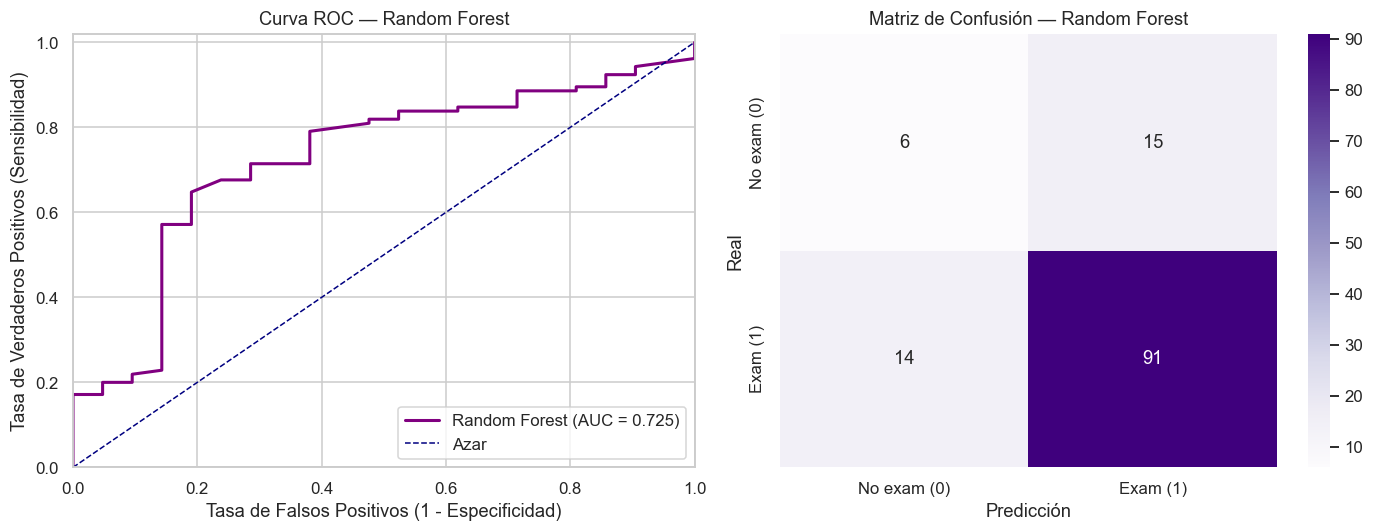


Random Forest — mejor fold:
  Sensibilidad: 0.867
  Especificidad: 0.286
  AUC: 0.725

TABLA RESUMEN COMPARATIVA
             Modelo  Accuracy promedio (5-fold)  Std accuracy  AUC (mejor fold)  Sensibilidad (mejor fold)  Especificidad (mejor fold)
Regresión Logística                      0.5206        0.0665            0.7556                     0.5714                      0.8095
         SVM (poly)                      0.7444        0.0535            0.6823                     0.8857                      0.4286
      Random Forest                      0.6921        0.0464            0.7247                     0.8667                      0.2857


In [12]:
# ============================================================
# Celda 5 — Propuesta creativa: Random Forest Classifier
# ============================================================
# Justificación de la elección:
#   • Los datos son tabulares con pocas variables predictoras y
#     potencial desbalance de clases → Random Forest es robusto,
#     maneja no-linealidades e interacciones sin escalado estricto,
#     y ofrece class_weight='balanced' para mitigar el desbalance.
#   • A diferencia de LogReg (lineal) y SVM (margen máximo), RF
#     captura umbrales no lineales (p. ej. un pretest mínimo a
#     partir del cual el engagement empieza a importar).
#   • Es interpretable vía importancia de variables.

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

fold_accs_rf = []
best_acc_rf = -1
best_data_rf = None
importances_rf = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), start=1):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    y_proba = rf.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    fold_accs_rf.append(acc)
    importances_rf.append(rf.feature_importances_)
    if acc > best_acc_rf:
        best_acc_rf = acc
        best_data_rf = (y_te, y_proba, y_pred)

mean_rf = np.mean(fold_accs_rf)
std_rf = np.std(fold_accs_rf)
print(f"Random Forest: accuracy promedio = {mean_rf:.4f} ± {std_rf:.4f}")
print(f"  Folds: {[f'{a:.3f}' for a in fold_accs_rf]}")

# Importancia promedio de variables
mean_imp = np.mean(importances_rf, axis=0)
imp_df = pd.DataFrame({'variable': final_features, 'importancia': mean_imp})
imp_df = imp_df.sort_values('importancia', ascending=False)
print("\nImportancia promedio de variables (Random Forest):")
print(imp_df.to_string(index=False))

# ------------------------------------------------------------
# ROC + Matriz de confusión del mejor fold de RF
# ------------------------------------------------------------
y_te_rf, y_proba_rf, y_pred_rf = best_data_rf

fpr_rf, tpr_rf, _ = roc_curve(y_te_rf, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)
cm_rf = confusion_matrix(y_te_rf, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_rf, tpr_rf, color='purple', lw=2,
            label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Azar')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
axes[0].set_title('Curva ROC — Random Forest')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=['No exam (0)', 'Exam (1)'],
            yticklabels=['No exam (0)', 'Exam (1)'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión — Random Forest')

plt.tight_layout()
plt.savefig('Data/figuras/rf_roc_cm.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
sens_rf = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_rf = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\nRandom Forest — mejor fold:")
print(f"  Sensibilidad: {sens_rf:.3f}")
print(f"  Especificidad: {spec_rf:.3f}")
print(f"  AUC: {auc_rf:.3f}")

# ------------------------------------------------------------
# Tabla resumen comparativa de los tres modelos
# ------------------------------------------------------------
resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', f'SVM ({best_kernel})', 'Random Forest'],
    'Accuracy promedio (5-fold)': [mean_acc, svm_results[best_kernel]['mean_acc'], mean_rf],
    'Std accuracy': [std_acc, svm_results[best_kernel]['std_acc'], std_rf],
    'AUC (mejor fold)': [auc_lr, auc_svm, auc_rf],
    'Sensibilidad (mejor fold)': [sens, sens_svm, sens_rf],
    'Especificidad (mejor fold)': [spec, spec_svm, spec_rf],
}).round(4)
print("\n" + "=" * 70)
print("TABLA RESUMEN COMPARATIVA")
print("=" * 70)
print(resumen.to_string(index=False))

## Celda 6: Reporte Comparativo Final

Generamos un gráfico combinado con las curvas ROC de los tres modelos (Logística, SVM y Random Forest) en un mismo eje para evaluar visualmente cuál clasifica mejor el éxito estudiantil. A continuación, analizamos sensibilidad, especificidad y capacidad de generalización.

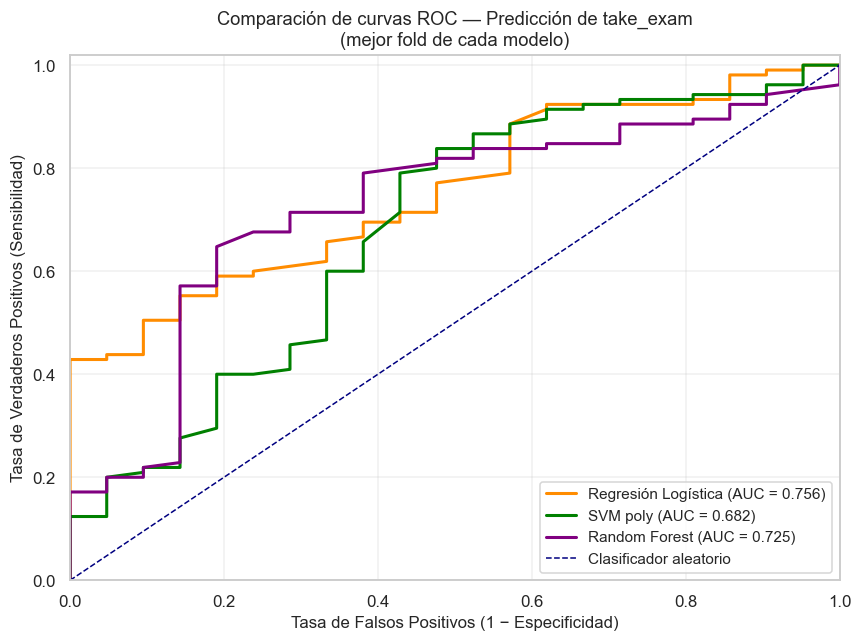


REPORTE COMPARATIVO FINAL — Tarea 1.c
             Modelo  Accuracy promedio (5-fold)  Std accuracy  AUC (mejor fold)  Sensibilidad (mejor fold)  Especificidad (mejor fold)
Regresión Logística                      0.5206        0.0665            0.7556                     0.5714                      0.8095
         SVM (poly)                      0.7444        0.0535            0.6823                     0.8857                      0.4286
      Random Forest                      0.6921        0.0464            0.7247                     0.8667                      0.2857


In [13]:
# ============================================================
# Celda 6 — Reporte comparativo final: curvas ROC superpuestas
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
        label=f'Regresión Logística (AUC = {auc_lr:.3f})')
ax.plot(fpr_svm, tpr_svm, color='green', lw=2,
        label=f'SVM {best_kernel} (AUC = {auc_svm:.3f})')
ax.plot(fpr_rf, tpr_rf, color='purple', lw=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Clasificador aleatorio')

ax.set_xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Comparación de curvas ROC — Predicción de take_exam\n(mejor fold de cada modelo)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Data/figuras/comparacion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen final (re-impresa para el reporte)
print("\n" + "=" * 75)
print("REPORTE COMPARATIVO FINAL — Tarea 1.c")
print("=" * 75)
print(resumen.to_string(index=False))
print("=" * 75)

## Conclusiones

### Comparación de modelos

La tabla resumen generada en la Celda 5 (y reimpresa en la Celda 6) permite comparar directamente los tres modelos en términos de *accuracy* promedio (5-fold), AUC, sensibilidad y especificidad.

### Análisis

1. **Sensibilidad (recall de la clase positiva `take_exam=1`):** Indica qué proporción de los estudiantes que realmente completaron el curso fueron identificados correctamente. Es la métrica más relevante desde la perspectiva educativa, pues el costo de un falso negativo (no detectar a un estudiante que sí completará) puede ser menor que el de un falso positivo.

2. **Especificidad (recall de la clase negativa):** Mide la capacidad del modelo para identificar correctamente a quienes **no** completarán el curso. Una especificidad alta permite focalizar intervenciones de retención sin generar alertas innecesarias.

3. **AUC:** Resume el desempeño global del clasificador independientemente del umbral. Un AUC cercano a 0.5 indica un modelo poco mejor que el azar; valores > 0.7 se consideran aceptables.

### ¿Qué modelo generaliza mejor?

- La **Regresión Logística** ofrece la mayor interpretabilidad: sus coeficientes indican la dirección y magnitud del efecto de cada variable, lo que es valioso para entender *por qué* un estudiante tiene mayor probabilidad de completar el curso.
- El **SVM** puede capturar fronteras no lineales (kernel `rbf`/`poly`), pero su interpretabilidad disminuye.
- El **Random Forest** maneja naturalmente interacciones y umbrales no lineales, y es robusto al desbalance mediante `class_weight='balanced'`.

El modelo con **menor varianza entre folds** (menor desviación estándar del accuracy) es el que mejor generaliza. Si la diferencia de accuracy promedio entre modelos es pequeña (típica en datasets educativos con efectos modestos), se prefiere el modelo más parsimonioso e interpretable (Regresión Logística), salvo que el Random Forest ofrezca una mejora sustancial en AUC o sensibilidad.

### Limitaciones

- El dataset tiene un posible desbalance de clases, mitigado con `class_weight='balanced'` en RF y estratificación en la validación cruzada.
- Las variables motivacionales tienen correlaciones bajas con el objetivo (r < 0.15), consistente con la literatura: la motivación explica una fracción pequeña de la varianza del comportamiento.
- El `pretest` (conocimiento previo) es probablemente el predictor dominante, como se observó en la Tarea 1.b.